# Geo-Disasters Event Footprints

Where the EM-DAT events happened, as administrative-unit geometry, from Teber and coauthors at the
Max Planck Institute for Biogeochemistry. EM-DAT names a country and writes the affected places as
free text. This resolves that text to units on the ground, which is what lets an event be matched to
a grid cell.

## Provenance

These are the fields of the `GEO_DISASTERS` declaration in `climate_risk/data/geo_disasters.py`. It
is a `ManualSource`: the GeoPackage is downloaded from Zenodo by hand and placed in the cache.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.geo_disasters import GEO_DISASTERS

declared = {"publisher": "Max Planck Institute for Biogeochemistry"} | dataclasses.asdict(GEO_DISASTERS)
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | Max Planck Institute for Biogeochemistry |
| filename | disaster_subnational_90_23.gpkg |
| homepage | https://doi.org/10.5281/zenodo.15487667 |
| license | Spatial geometries are © FAO 2015 under the GAUL 2015 Data License, non-commercial with attribution required. All non-spatial attributes are CC-BY-4.0. |
| citation | Teber, K., Weynants, M., Gans, F., & Mahecha, M. D. (2025). Geo-Disasters v1.0.0: geocoded EM-DAT climate-disaster footprints (1990-2023). https://doi.org/10.5281/zenodo.15487667 |
| retrieved | 2026-08-09 |

## Loading it

Two loaders read the same GeoPackage. `load_event_locations` returns the event-to-unit rows without
geometry, which is what a join needs. `load_event_footprints` returns the polygons for one country.
The cache directory is your choice, and this page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

import climate_risk as cr

from climate_risk.data.geo_disasters import load_event_footprints, load_event_locations
from climate_risk.data_functions.emdat_processing import load_emdat_events
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")
COUNTRY = "LAO"

locations = load_event_locations(cache_dir)
footprints = load_event_footprints(cache_dir, iso=COUNTRY)

## What you get

`load_event_locations` gives a pandas frame, one row per event and unit, so an event touching nine
provinces is nine rows. `load_event_footprints` gives a GeoDataFrame in EPSG:4326 with the same keys
and the unit geometry attached.

In [4]:
locations.head()

,DisNo.,ADM1_NAME,ADM2_NAME,ISO,admin_level,geocoding_q
0,1990-0001-LKA,Eastern,Ampara,LKA,2,2
1,1990-0001-LKA,Uva,Moneragala,LKA,2,2
2,1990-0001-LKA,Uva,Badulla,LKA,2,2
3,1990-0001-LKA,Central,Matale,LKA,2,2
4,1990-0001-LKA,Central,Nuwara Eliya,LKA,2,2


In [5]:
footprints[["DisNo.", "ADM1_NAME", "ADM2_NAME", "admin_level", "geocoding_q", "geometry"]].head()

,DisNo.,ADM1_NAME,ADM2_NAME,admin_level,geocoding_q,geometry
0,1991-0761-LAO,Savannakhet,NaN,1,2,"POLYGON ((104.73287 16.93251, 104.73413 16.955..."
1,1991-0761-LAO,Khammouan,NaN,1,2,"MULTIPOLYGON (((104.2794 17.86903, 104.36279 1..."
2,1995-0229-LAO,Xekong,NaN,1,2,"POLYGON ((106.29921 15.44977, 106.30071 15.469..."
3,1995-0229-LAO,Savannakhet,NaN,1,2,"POLYGON ((104.73287 16.93251, 104.73413 16.955..."
4,1995-0229-LAO,Bolikhamxai,NaN,1,2,"POLYGON ((102.82172 18.51072, 102.83197 18.517..."


## Units

| Column | Unit |
|---|---|
| `DisNo.` | the EM-DAT event identifier this row belongs to |
| `ISO` | ISO 3166-1 alpha-3 country code |
| `ADM1_NAME`, `ADM2_NAME` | unit names as GAUL 2015 spells them |
| `ADM1_CODE`, `ADM2_CODE` | GAUL unit identifiers |
| `admin_level` | 1 or 2, which of the two names keys the row |
| `geocoding_q` | the publisher's geocoding quality flag |
| `geometry` | polygon, degrees in EPSG:4326 |

`admin_level` is the one to read first. It says whether a row is a province or a district, and the
frame mixes both, so counting rows counts units at two different sizes.

## Coverage

The source covers climate disasters between 1990 and 2023, and EM-DAT runs from 1900 to the present
over every disaster type. Joining the two without narrowing to that window suggests two thirds of
the record is unmapped. Inside the window and the disaster classes this source covers, the match is
almost complete.

In [6]:
events = load_emdat_events(cache_dir)
located = set(locations["DisNo."])

in_window = events.filter(pl.col("Start_Year").dt.year().is_between(1990, 2023))
scopes = {
    "every EM-DAT event": events,
    "1990 to 2023": in_window,
    "1990 to 2023, climate only": in_window.filter(pl.col("disaster_class").is_not_null()),
}

pl.DataFrame(
    [
        {
            "scope": name,
            "events": frame.height,
            "with a footprint": frame.filter(pl.col("DisNo.").is_in(located)).height,
        }
        for name, frame in scopes.items()
    ]
).with_columns((pl.col("with a footprint") / pl.col("events")).alias("share"))

scope,events,with a footprint,share
str,i64,i64,f64
"""every EM-DAT event""",27758,9139,0.329238
"""1990 to 2023""",20571,9139,0.444266
"""1990 to 2023, climate only""",10425,9121,0.874916


## A plot

Every Lao footprint drawn over the country, one polygon per event and unit. They are translucent, so
ground that several events reached comes out darker. The units are the ones the source resolved to,
and a unit no event touched is simply not drawn. The
darkest ground is the southern Mekong corridor.

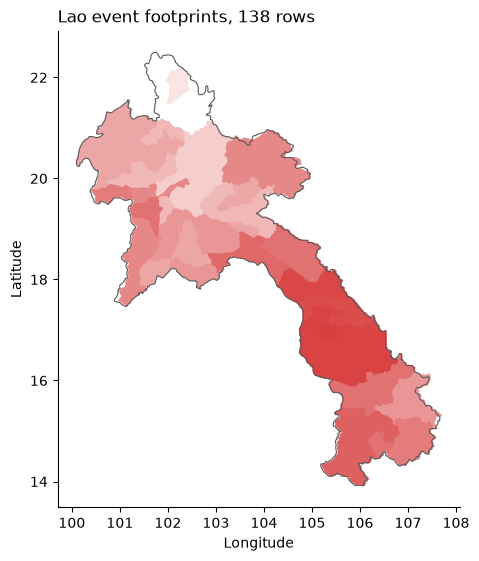

In [7]:
world = cr.load_shapefile("world", cache_dir)
country = world.query("ISO_A3 == @COUNTRY")

figure, axis = plt.subplots(figsize=(5.0, 5.5))
country.boundary.plot(ax=axis, color=PALETTE["divider"], lw=0.8)
footprints.plot(ax=axis, color=PALETTE["secondary"], alpha=0.12, edgecolor="none")

axis.set_title(f"Lao event footprints, {len(footprints)} rows", loc="left")
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.grid(False)

plt.show()

## Gotchas

*The geometry and the attributes are licensed differently.* The polygons are FAO GAUL 2015, which is
non-commercial with attribution. The non-spatial columns are CC BY 4.0. Anything that ships a map
made from this carries the stricter of the two.

*It covers 1990 to 2023 and climate disasters only.* An event outside that window or of another type
is absent rather than unlocated, and a left join onto the full EM-DAT record fills those rows with
nulls that mean "not in scope".

*Rows mix two administrative levels.* `admin_level` says which, and a province row and a district row
are not comparable areas. Summing over rows without reading it double-counts the ground.

*One event is many rows.* `load_event_locations` keys on event and unit together, so counting rows
counts affected units. `DisNo.` is what to count for events.

*Unit names come from GAUL 2015, not from GADM.* The two disagree on spellings and on which units
exist, so joining this to a GADM layer by name rather than by geometry drops units silently.